# Goal: Forecast daily ward occupancy Load

### Models used in this assignment:

Here's a short explanation of the models used and why they are suitable for this problem:

*   **Prophet:** This is a time series forecasting model developed by Facebook. It's designed for time series data that has strong seasonal effects and holidays. In this problem, ward occupancy data likely exhibits daily, weekly, and potentially yearly seasonality, making Prophet a suitable choice for capturing these patterns. It also handles missing data and outliers well.

*   **Random Forest:** This is an ensemble learning method that builds multiple decision trees and merges their predictions to get a more accurate and stable forecast. It can capture non-linear relationships between the features (like lag occupancy and time-based features) and the target variable (occupancy). It's suitable here because we've engineered features that represent past occupancy and temporal patterns, which Random Forest can leverage.

*   **XGBoost:** This is another powerful gradient boosting algorithm that is an improvement over traditional gradient boosting. It's known for its speed and performance in various machine learning tasks, including regression. Similar to Random Forest, it can model complex relationships between the engineered features and occupancy. Its boosting approach often leads to higher accuracy compared to Random Forest, making it a good candidate for this forecasting problem.

Both Random Forest and XGBoost are suitable because they can utilize the engineered features (lagged occupancy, day of week, month) to predict future occupancy, treating it as a regression problem based on historical patterns and temporal information.


 ### Planning: ###

1.  **Mount Google Drive and Install Libraries:** Access dataset from Google Drive and install necessary libraries.
2.  **Load and Demo the Dataset:** Load `transfers.csv` and perform basic exploration.
3.  **Exploratory Data Analysis (EDA):** Analyze `transfers` table for data quality, feature selection, and cleaning needs.
4.  **Aggregate Daily Ward Occupancy:** Calculate daily occupancy from transfer data.
5.  **Time Series Forecasting with Prophet:** Build and evaluate a Prophet model for forecasting.
6.  **Feature Engineering for Machine Learning Models:** Create time-based and lag features.
7.  **Random Forest Model:** Train, evaluate, and interpret a Random Forest model.
8.  **XGBoost Model:** Train, evaluate, and interpret an XGBoost model.


**Tables used:**

*   `transfers.csv`

**Columns Used (from `transfers`):**

*   `ROW_ID`, `SUBJECT_ID`, `HADM_ID`, `ICUSTAY_ID`: Identifiers.
*   `PREV_CAREUNIT`, `CURR_CAREUNIT`: Used for tracking care unit changes.
*   `INTIME`, `OUTTIME`: Used for calculating duration and creating occupancy events.
*   `DBSOURCE`, `EVENTTYPE`, `PREV_WARDID`, `CURR_WARDID`, `LOS`: Available for potential analysis but not explicitly used in the current code.

# Prerequisites

*   **Refer the Python code and Data set:** Obtain the necessary Python code and dataset from the specified GitHub Project. Git URL : https://github.com/gsmanivel/sla-assignment
*   **Place the Python code and dataset in Google Drive:** Ensure the downloaded files are stored in your Google Drive.
*   **Update the dataset path:** Accurately update the `data_path` variable in the code to point to the location of the dataset in your Google Drive.
*   **Run every step:** Execute each code cell sequentially to ensure the notebook runs as expected.

# Step 1 : Mount drive and install libraries

In [1]:
# Mount Google Drive to access the dataset
from google.colab import drive
import os

drive.mount('/content/drive') # Mount Google Drive at /content/drive

# Define the path to the dataset in your Google Drive
data_path = '/content/drive/MyDrive/Colab Notebooks/mimic-iii'

# List the contents of the data directory to verify the dataset is accessible
os.listdir(data_path)

# Install required libraries using pip. The ! prefix runs the command in the shell.
# pandas for data manipulation and analysis
# numpy for numerical operations
# matplotlib and seaborn for data visualization
# scikit-learn for machine learning algorithms (used later for Random Forest)
# xgboost for gradient boosting (used later for XGBoost)
# statsmodels for statistical modeling
# xgboost is used for gradient boosting, another machine learning algorithm.
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels matplotlib xgboost prophet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2 : Load  & Demo the dataset

In [2]:
import pandas as pd

# Load the datasets from the specified data_path into pandas DataFrames

# transfers.csv contains information about patient transfers within the hospital
transfers = pd.read_csv(f'{data_path}/transfers.csv')

/tmp/ipython-input-2213191964.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  transfers = pd.read_csv(f'{data_path}/transfers.csv')


In [3]:
# Below code is to have a quick look
# This section provides a basic overview of the 'transfers' DataFrame

# Basic Transfer Table overview - Print a descriptive header
print('Basic Transfer Table overview')

# Shape (Quick size check) - Display the number of rows and columns
print("Transfer Dataset Shape:")
display(transfers.shape)

# Info (Quick overview of structure) - Display column names, non-null counts, and data types
print("Transfer Dataset Info:")
display(transfers.info())

# Head (Display first 5 lines) - Display the first 5 rows of the DataFrame
print("Transfer Dataset head:")
display(transfers.head())

Basic Transfer Table overview
Transfer Dataset Shape:


(261897, 13)

Transfer Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261897 entries, 0 to 261896
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ROW_ID         261897 non-null  int64  
 1   SUBJECT_ID     261897 non-null  int64  
 2   HADM_ID        261897 non-null  int64  
 3   ICUSTAY_ID     87721 non-null   float64
 4   DBSOURCE       261656 non-null  object 
 5   EVENTTYPE      261873 non-null  object 
 6   PREV_CAREUNIT  96009 non-null   object 
 7   CURR_CAREUNIT  96016 non-null   object 
 8   PREV_WARDID    202964 non-null  float64
 9   CURR_WARDID    202954 non-null  float64
 10  INTIME         261873 non-null  object 
 11  OUTTIME        202921 non-null  object 
 12  LOS            202921 non-null  float64
dtypes: float64(4), int64(3), object(6)
memory usage: 26.0+ MB


None

Transfer Dataset head:


,ROW_ID,SUBJECT_ID,HADM_ID,ICUSTAY_ID,DBSOURCE,EVENTTYPE,PREV_CAREUNIT,CURR_CAREUNIT,PREV_WARDID,CURR_WARDID,INTIME,OUTTIME,LOS
0,3831,690,174817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5690,1010,138250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8152,1490,135580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18207,3369,126808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27059,5008,176430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Step 3: Exploratory Data Analysis


Below code is to perform Exploratory Data Analysis of the `transfers` table

Below are the key outcomes and benefits of performing this EDA:

1.  **Understand Data Quality**: Identify missing values, inconsistencies, and potential errors in the datasets. This step is crucial for knowing which columns require cleaning or imputation before further analysis or modeling.
2.  **Feature Selection**: Get an initial sense of which features (columns) might be most relevant for the task at hand (e.g., predicting hospital occupancy). Visualizations and summary statistics can highlight important variables.
3.  **Identify Areas for Data Cleaning**: Based on the data quality assessment, determine specific steps needed to handle missing data (e.g., imputation, dropping rows/columns) or correct incorrect data formats or values.
4.  **Insights for Modeling**: Discover patterns, trends, and distributions within the data through visualizations. For time-series data like ward occupancy, visual patterns (e.g., seasonality, skewness) can guide feature engineering (e.g., adding lag features, rolling statistics) and model selection.


In [4]:
# Check for missing values in the transfers DataFrame
print("Missing values in transfers table:")
display(transfers.isnull().sum())

Missing values in transfers table:


,0
ROW_ID,0
SUBJECT_ID,0
HADM_ID,0
ICUSTAY_ID,174176
DBSOURCE,241
EVENTTYPE,24
PREV_CAREUNIT,165888
CURR_CAREUNIT,165881
PREV_WARDID,58933
CURR_WARDID,58943


In [5]:
# Check the number of unique values in key identifier columns to understand the scale of the data
print("\nUnique values in identifier columns:")
display(transfers[['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID']].nunique())


Unique values in identifier columns:


,0
ROW_ID,261897
SUBJECT_ID,46520
HADM_ID,58976
ICUSTAY_ID,61532


In [6]:
# Examine the distribution of categorical columns like DBSOURCE, EVENTTYPE, PREV_CAREUNIT, CURR_CAREUNIT
print("\nValue counts for categorical columns:")
print("\nDBSOURCE distribution:")
display(transfers['DBSOURCE'].value_counts(dropna=False))

print("\nEVENTTYPE distribution:")
display(transfers['EVENTTYPE'].value_counts(dropna=False))

print("\nPREV_CAREUNIT distribution:")
display(transfers['PREV_CAREUNIT'].value_counts(dropna=False))

print("\nCURR_CAREUNIT distribution:")
display(transfers['CURR_CAREUNIT'].value_counts(dropna=False))


Value counts for categorical columns:

DBSOURCE distribution:


,count
DBSOURCE,
carevue,161797
metavision,99306
both,553
NaN,241



EVENTTYPE distribution:


,count
EVENTTYPE,
transfer,144045
discharge,58919
admit,58909
NaN,24



PREV_CAREUNIT distribution:


,count
PREV_CAREUNIT,
NaN,165888
MICU,26398
NICU,18631
CSRU,13662
SICU,11321
CCU,9534
NWARD,8297
TSICU,8166



CURR_CAREUNIT distribution:


,count
CURR_CAREUNIT,
NaN,165881
MICU,26400
NICU,18629
CSRU,13663
SICU,11323
CCU,9542
NWARD,8295
TSICU,8164


In [7]:
# Check the data types of the columns
print("\nData types of transfers columns:")
display(transfers.dtypes)


Data types of transfers columns:


,0
ROW_ID,int64
SUBJECT_ID,int64
HADM_ID,int64
ICUSTAY_ID,float64
DBSOURCE,object
EVENTTYPE,object
PREV_CAREUNIT,object
CURR_CAREUNIT,object
PREV_WARDID,float64
CURR_WARDID,float64


# Step 4: Aggregate Daily Ward Occupancy Across All Wards




Below code aggregates patient's transfer data to calculate daily ward occupancy using an event-based approach:

*   Converts `INTIME` and `OUTTIME` to datetime objects.
*   Drops rows with missing critical occupancy information.
*   Calculates the duration of stay.
*   Creates 'arrival' (+1 occupancy) and 'departure' (-1 occupancy) events.
*   Combines and sorts all events chronologically.
*   Calculates the cumulative sum of occupancy changes for each ward.
*   Resamples the data to a daily frequency, taking the last observation of the day and forward-filling missing days.
*   Renames the final DataFrame to `ward_ts`.

This process transforms raw transfer data into a daily time series of ward occupancy.

In [8]:
import pandas as pd # Import pandas for data manipulation

# Convert INTIME and OUTTIME columns to datetime objects
# errors='coerce' will turn invalid date formats into NaT (Not a Time)
transfers['INTIME'] = pd.to_datetime(transfers['INTIME'], errors='coerce')
transfers['OUTTIME'] = pd.to_datetime(transfers['OUTTIME'], errors='coerce')

# Drop rows with missing values in the critical columns needed for occupancy calculation
full_data = transfers.dropna(subset=['CURR_CAREUNIT', 'INTIME', 'OUTTIME'])

# Calculate the duration of stay in hours
# Ensure OUTTIME is greater than INTIME before calculating duration to avoid negative durations
full_data['duration_hours'] = (full_data['OUTTIME'] - full_data['INTIME']).dt.total_seconds() / 3600
# Keep only rows with non-negative durations
full_data = full_data[full_data['duration_hours'] >= 0]
# Convert duration to integer hours
full_data['duration_hours'] = full_data['duration_hours'].astype(int)


# Generate occupancy records using an event-based cumulative sum approach for efficiency.
# This is more efficient than iterating through rows and generating date ranges.

# Create 'arrival' events: a person enters a ward, increasing occupancy by 1
arrivals = full_data[['CURR_CAREUNIT', 'INTIME']].copy() # Select relevant columns
arrivals['occupancy_change'] = 1 # Mark as an increase in occupancy
arrivals = arrivals.rename(columns={'INTIME': 'timestamp', 'CURR_CAREUNIT': 'ward'}) # Rename columns for clarity

# Create 'departure' events: a person leaves a ward, decreasing occupancy by 1
departures = full_data[['CURR_CAREUNIT', 'OUTTIME']].copy() # Select relevant columns
departures['occupancy_change'] = -1 # Mark as a decrease in occupancy
departures = departures.rename(columns={'OUTTIME': 'timestamp', 'CURR_CAREUNIT': 'ward'}) # Rename columns for clarity

# Concatenate arrival and departure events into a single DataFrame
all_events = pd.concat([arrivals, departures])
# Sort all events chronologically by timestamp
all_events = all_events.sort_values(by='timestamp')

# Group events by ward and timestamp, summing the occupancy changes at each event
occupancy_changes = all_events.groupby(['ward', 'timestamp'])['occupancy_change'].sum().reset_index()

# Calculate the cumulative sum of occupancy changes for each ward over time
# This gives the running occupancy for each ward
occupancy_changes['occupancy'] = occupancy_changes.groupby('ward')['occupancy_change'].cumsum()

# Drop the intermediate 'occupancy_change' column as it's no longer needed
occupancy_changes = occupancy_changes.drop(columns='occupancy_change')

# Resample the data to a daily frequency and take the last observation of the day as the daily occupancy.
# Fill missing values (days with no events) by carrying the last known occupancy forward (forward fill).
# Pivot the table to have timestamps as index, wards as columns, and occupancy as values
occupancy_ts = occupancy_changes.pivot_table(index='timestamp', columns='ward', values='occupancy', fill_value=0)
# Forward fill to propagate the last valid observation forward
occupancy_ts = occupancy_ts.ffill()

# Resample to daily frequency ('D') and take the last recorded occupancy for each day
# Fill any remaining NaNs (e.g., at the very beginning) with 0
daily_occupancy = occupancy_ts.resample('D').last().fillna(0)

# Rename the resulting DataFrame to ward_ts to align with subsequent cells that use this variable name
ward_ts = daily_occupancy.reset_index().rename(columns={'timestamp': 'date'})

# Display descriptive statistics of the resulting daily ward occupancy DataFrame
display(ward_ts.describe())

/tmp/ipython-input-1892088646.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_data['duration_hours'] = (full_data['OUTTIME'] - full_data['INTIME']).dt.total_seconds() / 3600


ward,date,CCU,CSRU,MICU,NICU,NWARD,SICU,TSICU
count,40251,40251.000000,40251.000000,40251.000000,40251.000000,40251.000000,40251.000000,40251.000000
mean,2155-07-13 23:59:59.999998976,0.121835,0.121090,0.884649,0.282875,0.056222,0.252391,0.111550
min,2100-06-07 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2127-12-25 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2155-07-14 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2183-01-30 12:00:00,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
max,2210-08-20 00:00:00,5.000000,8.000000,10.000000,10.000000,4.000000,8.000000,5.000000
std,NaN,0.465146,0.504041,1.513036,0.952841,0.284933,0.751263,0.446411


In [9]:
import pandas as pd # Import pandas for data manipulation

# Sum the occupancy of all  wards into a single column named 'ALL'. The reason : Data is not sufficient to display for each ward. Hence i am predicting overall ward occupancy load.In future,if we get proper data, we can do slight change
# in this place to perform each ward prediction.
all_wards_ts = ward_ts[['date']].copy()
all_wards = ['CCU', 'CSRU', 'NICU', 'NWARD', 'SICU', 'TSICU','MICU']
# Sum the values across these columns for each date and store in 'Others'
all_wards_ts['ALL'] = ward_ts[all_wards].sum(axis=1)

# Convert the 'date' column to datetime objects
all_wards_ts['date'] = pd.to_datetime(all_wards_ts['date'])
# Sort the DataFrame by date and reset the index
all_wards_ts = all_wards_ts.sort_values('date').reset_index(drop=True)

# Print descriptive statistics of the resulting DataFrame showing MICU vs Others occupancy
print(all_wards_ts.describe())

ward                            date           ALL
count                          40251  40251.000000
mean   2155-07-13 23:59:59.999998976      1.830613
min              2100-06-07 00:00:00      0.000000
25%              2127-12-25 12:00:00      1.000000
50%              2155-07-14 00:00:00      2.000000
75%              2183-01-30 12:00:00      3.000000
max              2210-08-20 00:00:00     11.000000
std                              NaN      1.555237


# Step 5: Time Series Forecasting with Prophet

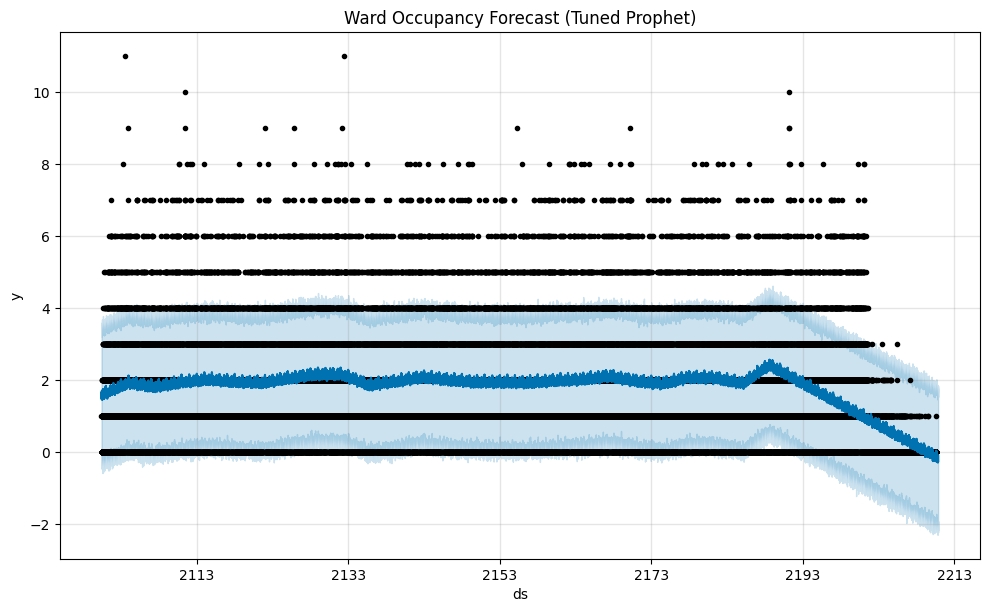

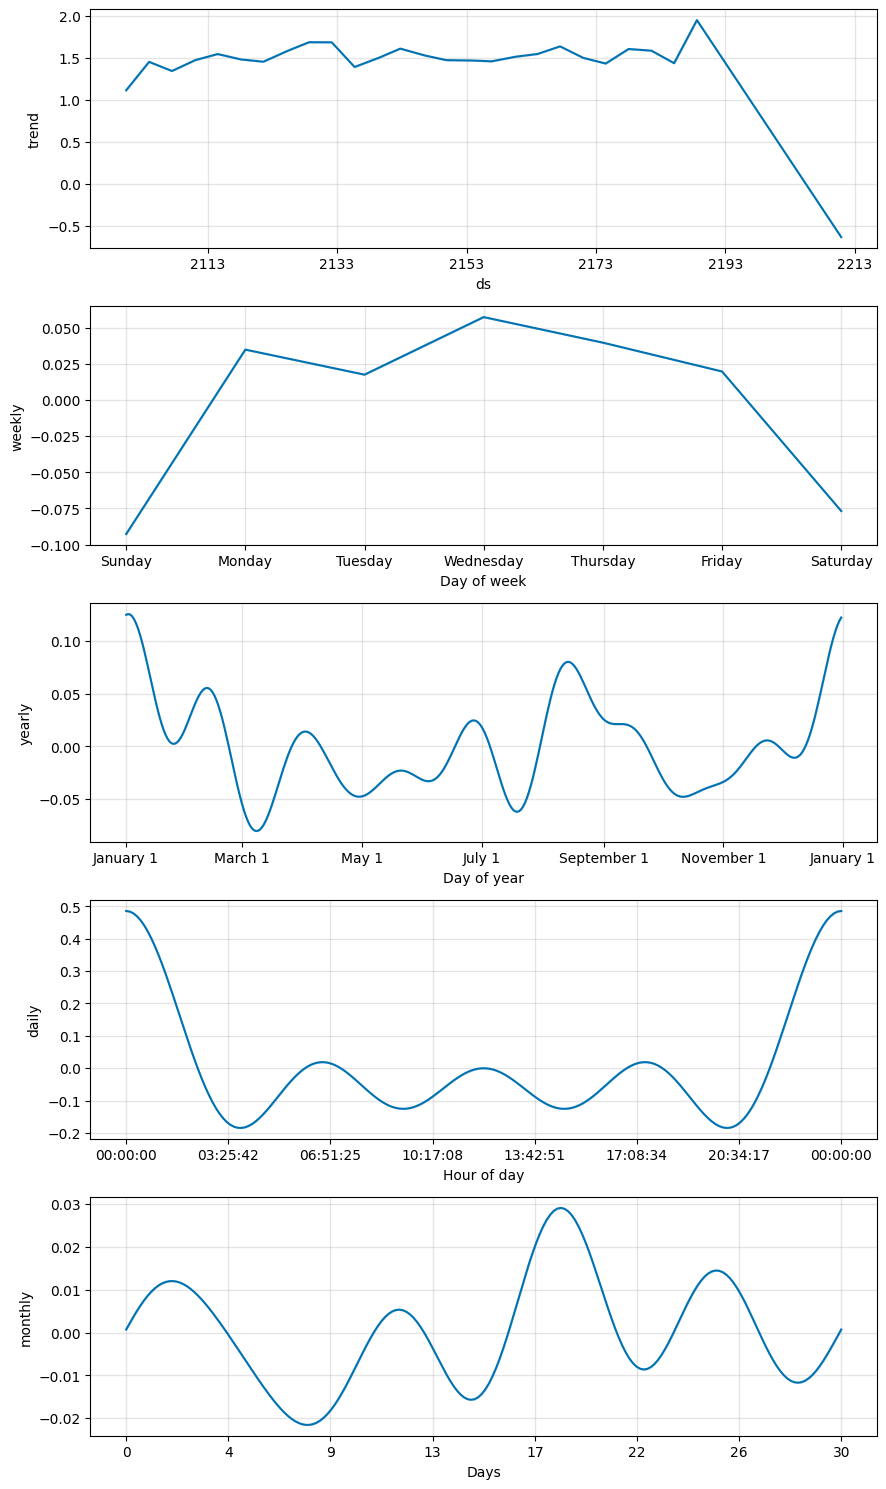

In [13]:
# Import Prophet for time series forecasting
from prophet import Prophet
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Prepare the data for the Prophet model
# Prophet requires the input DataFrame to have columns named 'ds' (datestamp) and 'y' (value)
all_df = all_wards_ts[['date', 'ALL']].rename(columns={'date': 'ds', 'ALL': 'y'})

# Initialize the Prophet model with specified seasonality options and prior scales
_model = Prophet(
    daily_seasonality=True, # Include daily seasonality component
    yearly_seasonality=True, # Include yearly seasonality component
    weekly_seasonality=True, # Include weekly seasonality component
    seasonality_mode='additive', # Use additive seasonality (seasonality effects are added to the trend)
    changepoint_prior_scale=0.5, # Adjust flexibility of changepoints (where the trend can change)
    seasonality_prior_scale=10 # Adjust the strength of the seasonality components
)

# Add a custom monthly seasonality component to the model
# name='monthly' gives the seasonality a name
# period=30.5 specifies the period of the seasonality in days (average number of days in a month)
# fourier_order=5 determines the flexibility of the monthly seasonality component
_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit the Prophet model to the historical MICU occupancy data
_model.fit(all_df)

# Create a future dataframe for forecasting
# make_future_dataframe generates a DataFrame with future dates
# periods=90 specifies the number of future periods to forecast (90 days)
# freq='D' specifies the frequency of the future dates (daily)
future_ = _model.make_future_dataframe(periods=90, freq='D')
# Predict future MICU occupancy using the fitted model
forecast_ = _model.predict(future_)

# Plot the forecast, including historical data and predicted future data
fig = _model.plot(forecast_)
plt.title("Ward Occupancy Forecast (Tuned Prophet)") # Set the title of the plot
plt.show() # Display the forecast plot

# Plot the components of the forecast (trend, yearly seasonality, weekly seasonality, daily seasonality, monthly seasonality)
fig2 = _model.plot_components(forecast_)
plt.show() # Display the components plot

# Prophet Plots - Quick look of above output:

Based on the nature of ward occupancy data and how Prophet models time series, here's a description of the expected patterns in the two lines (historical/actual and forecasted/predicted) in each diagram:

1.  **Ward Occupancy Forecast Plot (Historical Data vs. Forecast):**
    *   Black dots: Historical all ward occupancy data points.
    *   Blue line: Prophet’s predicted trend for all ward occupancy
    *  Light blue shaded area: Uncertainty interval for the forecast.
    *  The forecast extends beyond the historical data, showing a relatively stable trend with slight fluctuations.
    *  No strong upward or downward trend detected; occupancy remains mostly low.

2.  **Prophet Model Components Plots:** These plots show how different time-based factors contribute to the overall forecast. Each plot will typically show a single line representing the estimated impact of that component over time:
    *   **Trend Component:** Shows a mild increase followed by a slight decline toward the end of the forecast horizon. Indicates overall all ward occupancy is fairly stable over time.

    *   **Yearly Seasonality:** This line illustrates the typical pattern that repeats every year. Peaks around July and dips around January, indicating possible seasonal hospital load (summer higher, winter lower).

    *   **Weekly Seasonality:** This line shows the typical pattern that repeats every week. For ward occupancy, you might see consistent peaks and troughs corresponding to specific days of the week. Occupancy tends to be higher on Monday and Tuesday, then gradually decreases toward Saturday.Suggests weekday patterns in MICU admissions.

    *   **Additional Seasonal Components:** Monthly and daily cycles show oscillations, but no extreme variations. Confirms that all ward occupancy has some periodic behavior but remains generally low


#### Summary:

  * all ward occupancy is low and stable, with occasional spikes.
  * Prophet detected weekly and yearly seasonality, which can help in resource planning (e.g., staffing more on Mondays and in summer months).
  * Forecast uncertainty grows over time, which is expected for time-series models.

# Step 5.1: Prophet Model Evaluation

In [14]:
# Import Prophet for time series forecasting
from prophet import Prophet

# Import necessary metrics for evaluation from scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np # Import numpy to use np.sqrt for calculating RMSE


# Initialize and fit the Prophet model with default seasonality options
model = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
model.fit(all_df)

# Predict on the historical data to evaluate the model's performance on seen data
forecast = model.predict(all_df[['ds']])

# Merge the actual occupancy data with the predicted values
results = all_df.copy() # Create a copy of the original data
results['yhat'] = forecast['yhat'] # Add the predicted values ('yhat') as a new column

# Calculate evaluation metrics: Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE)
# Calculate Mean Squared Error (MSE) first
mse = mean_squared_error(results['y'], results['yhat'])
# Calculate Root Mean Squared Error (RMSE) by taking the square root of MSE
rmse = np.sqrt(mse)

# Filter out rows where actual occupancy is zero to avoid division by zero when calculating MAPE
non_zero_results = results[results['y'] > 0]

# Recalculate Mean Absolute Percentage Error (MAPE) using the filtered data
mape = mean_absolute_percentage_error(non_zero_results['y'], non_zero_results['yhat']) * 100
# Print the Adjusted MAPE (excluding zeros) formatted to two decimal places
print(f"Adjusted MAPE (excluding zeros): {mape:.2f}%")


# Print the Prophet model accuracy on historical MICU data, showing RMSE
print(f"Prophet Model Accuracy on Historical MICU Data:")
print(f"RMSE: {rmse:.2f}")

Adjusted MAPE (excluding zeros): 50.19%
Prophet Model Accuracy on Historical MICU Data:
RMSE: 1.48


# Prophet Model Evaluation Summary

A Prophet model was trained on historical MICU occupancy data with daily, weekly, and yearly seasonality enabled. Predictions were made on the historical dataset to evaluate performance. Accuracy metrics were calculated:

*   **RMSE (Root Mean Squared Error):** Measures the absolute error.
    *   **RMSE: 1.48** - On average, Prophet’s predictions differ from actual MICU occupancy by about 1.5 patients.

*   **MAPE (Mean Absolute Percentage Error):** Adjusted to exclude zero occupancy days to avoid division by zero.
    *   **Adjusted MAPE (excluding zeros): 50.19%** - Indicates percentage error is high because occupancy values are small (0–10), so even small absolute errors cause large percentage differences. What i feel is the data in transfers table needs more accurate data.

# Step 6: Feature Engineering for Machine Learning Models

### Feature Engineering

In the below Step, Prepare the data for machine learning models by creating time-based and lag features:

*   Selects 'date' and 'ALL' (renamed to 'occupancy') from `all_wards_ts`.
*   Converts 'date' to datetime and sorts the data.
*   Creates `dayofweek` and `month` features from the date.
*   Creates `lag1` (previous day's occupancy) and `lag7` (occupancy from 7 days ago) features using the `.shift()` method.
*   Removes rows with `NaN` values introduced by the lag features at the beginning of the time series.

These features provide temporal information and historical context for the models.

In [15]:
import pandas as pd # Import pandas for data manipulation

# Use the micu_vs_others DataFrame which contains daily MICU occupancy
all_data = all_wards_ts[['date', 'ALL']].copy()
# Rename the 'MICU' column to 'occupancy' for consistency
all_data = all_data.rename(columns={'ALL': 'occupancy'})

# Convert the 'date' column to datetime objects
all_data['date'] = pd.to_datetime(all_data['date'])
# Sort the DataFrame by date and reset the index
all_data = all_data.sort_values('date').reset_index(drop=True)


# Feature engineering: Create time-based features from the date
# Extract the day of the week (Monday=0, Sunday=6)
all_data['dayofweek'] = all_data['date'].dt.dayofweek
# Extract the month (1 for January, 12 for December)
all_data['month'] = all_data['date'].dt.month

# Feature engineering: Create lag features (previous days' occupancy)
# 'lag1' is the occupancy from the previous day (shift by 1)
all_data['lag1'] = all_data['occupancy'].shift(1)

# 'lag7' is the occupancy from 7 days ago (shift by 7)
all_data['lag7'] = all_data['occupancy'].shift(7)

# Drop rows that contain NaN values. These are introduced by the shift operations
# at the beginning of the time series where there are no previous days to lag from.
all_data = all_data.dropna()

# Step 7: Random Forest Model

### Random Forest Model Code Explanation

This code trains and evaluates a Random Forest Regressor model for ward occupancy forecasting:

1.  **Define Features and Target:**
    *   `X`: Contains the input features ('dayofweek', 'month', 'lag1', 'lag7').
    *   `y`: Contains the target variable ('occupancy').

2.  **Split Data:**
    *   Divides the data into training (80%) and testing (20%) sets using `train_test_split`.

3.  **Initialize and Train Model:**
    *   Creates a `RandomForestRegressor` instance with 200 estimators.
    *   Trains the model using the training data (`X_train`, `y_train`).

4.  **Predict and Evaluate:**
    *   Makes predictions on the test set (`X_test`).
    *   Calculates the Root Mean Squared Error (RMSE) between the actual (`y_test`) and predicted (`y_pred`) values to assess model performance.

In [16]:
# Import necessary modules from scikit-learn
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.ensemble import RandomForestRegressor # For the Random Forest regression model
from sklearn.metrics import mean_squared_error # For calculating Mean Squared Error
import numpy as np # Import numpy to use np.sqrt for calculating RMSE

# Define the features (X) and the target variable (y)
# X includes the engineered features: day of week, month, and lag features
X = all_data[['dayofweek', 'month', 'lag1', 'lag7']]
# y is the target variable: ALL occupancy
y = all_data['occupancy']

# Split the data into training and testing sets
# test_size=0.2 allocates 20% of the data to the test set and 80% to the training set
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train the Random Forest Regressor model
# n_estimators=200 specifies the number of trees in the forest
# random_state=42 ensures reproducibility of the model training
rf = RandomForestRegressor(n_estimators=200, random_state=42)
# Train the model using the training data
rf.fit(X_train, y_train)

# Predict the  occupancy on the test set using the trained model
y_pred = rf.predict(X_test)

# Evaluate the model's performance using Root Mean Squared Error (RMSE)
# Calculate Mean Squared Error (MSE) first
mse = mean_squared_error(y_test, y_pred)


# Calculate Root Mean Squared Error (RMSE) by taking the square root of MSE
rmse = np.sqrt(mse)


# Print the Random Forest RMSE formatted to two decimal places
print(f"Random Forest RMSE: {rmse:.2f}")

Random Forest RMSE: 1.53


### Random Forest Model Evaluation

The output `Random Forest RMSE: 1.53` indicates the Root Mean Squared Error for the Random Forest model's predictions on the test set.

*   **RMSE (Root Mean Squared Error):** This is a common metric for evaluating regression models. It measures the average magnitude of the errors between the predicted values and the actual values.
*   **Interpretation:** An RMSE of 1.53 means that, on average, the Random Forest model's predictions for daily ward occupancy differ from the actual occupancy by approximately 1.53 patients.

A lower RMSE indicates better model performance. You can compare this value to the RMSE obtained from other models (like Prophet and XGBoost) to determine which model provides a more accurate forecast for this specific problem.

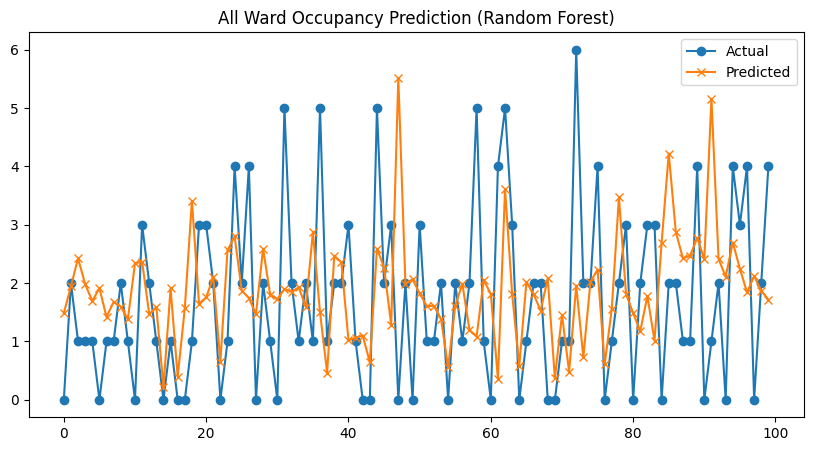

In [18]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Create a plot to visualize the actual vs predicted MICU occupancy for a subset of the test data
plt.figure(figsize=(10,5)) # Set the size of the plot
# Plot the first 100 actual values from the test set
plt.plot(y_test.values[:100], label='Actual', marker='o')
# Plot the first 100 predicted values from the test set
plt.plot(y_pred[:100], label='Predicted', marker='x')
plt.legend() # Display the legend to identify the lines
plt.title("All Ward Occupancy Prediction (Random Forest)") # Set the title of the plot
plt.show() # Display the plot

### Random Forest Prediction Plot Explanation

This code generates a line plot to visualize the performance of the Random Forest model on a subset of the test data:

*   It plots the actual ward occupancy values (`y_test`) against the predicted values (`y_pred`) for the first 100 data points in the test set.
*   Markers ('o' for Actual, 'x' for Predicted) are used to distinguish the two lines.
*   A legend is included to identify the lines, and the plot is titled "MICU Occupancy Prediction (Random Forest)".

**Interpretation:**

*   The chart compares actual MICU occupancy (blue line with circles) vs predicted occupancy (orange line with crosses) for 100 test samples using Random Forest.
*   Actual values fluctuate sharply between 0 and 6 patients, showing high variability and frequent spikes.
*   Predicted values are smoother and generally stay between 0 and 5 patients,capturing some trends but missing extreme peaks.

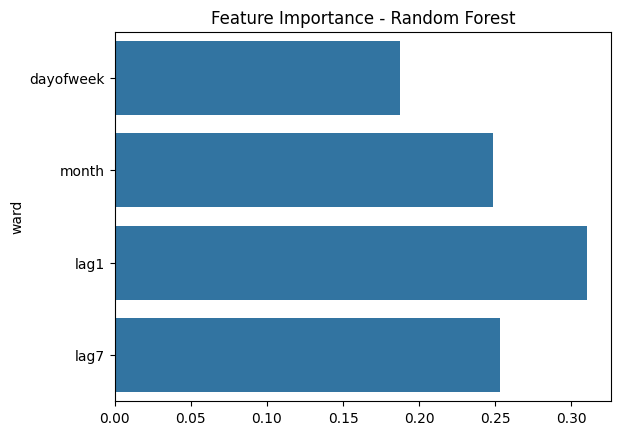

In [19]:
import seaborn as sns # Import seaborn for enhanced visualizations
import pandas as pd # Import pandas to create a Series for feature importance

# Get the feature importances from the trained Random Forest model
# Create a pandas Series with feature importances and the corresponding feature names as index
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
# Create a bar plot to visualize the feature importances
sns.barplot(x=feature_importance.values, y=feature_importance.index) # x-axis is importance values, y-axis is feature names
plt.title("Feature Importance - Random Forest") # Set the title of the plot
plt.show() # Display the plot

The above bar chart displays feature importance from the trained Random Forest model for MICU occupancy prediction.

**Features analyzed:**

*   `lag1` (previous day occupancy)
*   `lag7` (previous week occupancy)
*   `month`
*   `dayofweek`

**Interpretation of Feature Importance:**

*   `lag1` is the most important feature (~0.30), meaning yesterday’s occupancy strongly influences today’s occupancy.
*   `lag7` is the second most important (~0.25), indicating weekly patterns matter.
*   `month` and `dayofweek` have similar importance (~0.20 each), showing seasonal and weekly trends also contribute but less than lag features.

# Step 8: XGBoost Model

In [22]:
import pandas as pd # Import pandas for data manipulation

# Convert the 'date' column to datetime objects
all_data['date'] = pd.to_datetime(all_data['date'])
# Sort the DataFrame by date and reset the index
all_data = all_data.sort_values('date').reset_index(drop=True)

# Feature engineering: Create time-based and lag features
# Extract the day of the week (Monday=0, Sunday=6)
all_data['dayofweek'] = all_data['date'].dt.dayofweek
# Extract the month (1 for January, 12 for December)
all_data['month'] = all_data['date'].dt.month

# Lag features: Occupancy from previous days
# 'lag1' is the occupancy from the previous day
all_data['lag1'] = all_data['occupancy'].shift(1)

# 'lag7' is the occupancy from 7 days ago
all_data['lag7'] = all_data['occupancy'].shift(7)

# 'lag14' is the occupancy from 14 days ago
all_data['lag14'] = all_data['occupancy'].shift(14)

# Rolling mean feature: Calculate the mean occupancy over the past 7 days
all_data['rolling_mean_7'] = all_data['occupancy'].rolling(7).mean()

# Drop rows that contain NaN values. These are introduced by the shift and rolling mean operations
# at the beginning of the time series where there are not enough previous data points.
all_data = all_data.dropna()

### Feature Engineering for XGBoost

The above code prepares the data for the XGBoost model by creating additional time-based and lag features:

*   Starts with the 'date' and 'occupancy' data.
*   Converts 'date' to datetime and sorts the data.
*   Creates `dayofweek` and `month` features.
*   Creates lag features: `lag1`, `lag7`, and `lag14` (occupancy from the previous day, 7 days ago, and 14 days ago).
*   Creates a `rolling_mean_7` feature, which is the average occupancy over the past 7 days.
*   Removes rows with `NaN` values introduced by the lag and rolling mean calculations.

These additional features provide more historical context and smoothed information for the XGBoost model.

In [23]:
# Import train_test_split for splitting data
from sklearn.model_selection import train_test_split

# Define the features (X) and the target variable (y)
# X includes the engineered features: day of week, month, and multiple lag/rolling mean features
X = all_data[['dayofweek', 'month', 'lag1', 'lag7', 'lag14', 'rolling_mean_7']]
# y is the target variable: MICU occupancy
y = all_data['occupancy']

# Split the data into training and testing sets
# test_size=0.2 allocates 20% of the data to the test set
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Data Preparation for XGBoost

The above code prepares the data for the XGBoost model:

1.  **Define Features and Target:**
    *   `X`: Contains the input features, including the time-based features (`dayofweek`, `month`) and the engineered lag and rolling mean features (`lag1`, `lag7`, `lag14`, `rolling_mean_7`).
    *   `y`: Contains the target variable, which is the daily 'occupancy'.

2.  **Split Data:**
    *   Uses `train_test_split` to divide the data into training (80%) and testing (20%) sets.
    *   `test_size=0.2` specifies that 20% of the data will be used for testing.
    *   `random_state=42` ensures that the split is reproducible.

This step is crucial for evaluating the model's performance on unseen data.

In [24]:
# Import XGBoost Regressor model
from xgboost import XGBRegressor
# Import mean_squared_error for evaluation
from sklearn.metrics import mean_squared_error
# Import numpy to use np.sqrt for calculating RMSE
import numpy as np

# Initialize and train the XGBoost Regressor model
# n_estimators=500: Number of boosting rounds
# learning_rate=0.05: Step size shrinkage used in each boosting step
# max_depth=6: Maximum depth of a tree
# random_state=42: Ensures reproducibility
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
# Train the model using the training data
xgb.fit(X_train, y_train)

# Predict the MICU occupancy on the test set using the trained model
y_pred = xgb.predict(X_test)

# Evaluate the model's performance using Root Mean Squared Error (RMSE)
# Calculate Mean Squared Error (MSE) first
mse = mean_squared_error(y_test, y_pred)
# Calculate Root Mean Squared Error (RMSE) by taking the square root of MSE
rmse = np.sqrt(mse)
# Print the XGBoost RMSE formatted to two decimal places
print(f"XGBoost RMSE: {rmse:.2f}")

XGBoost RMSE: 1.31


The above code trains an XGBoost Regressor model to predict ward occupancy.

1.  **Import Libraries**: Imports `XGBRegressor`, `mean_squared_error`, and `numpy`.
2.  **Initialize Model**: Sets up the `XGBRegressor` with hyperparameters like `n_estimators`, `learning_rate`, and `max_depth`.
3.  **Train Model**: Fits the model to the training data (`X_train`, `y_train`).
4.  **Predict**: Makes predictions on the test data (`X_test`).
5.  **Evaluate**: Calculates the Root Mean Squared Error (RMSE) between actual and predicted values.

The output `XGBoost RMSE: 1.31` indicates that, on average, the model's predictions differ from actual occupancy by about 1.31 patients. A lower RMSE means better performance.

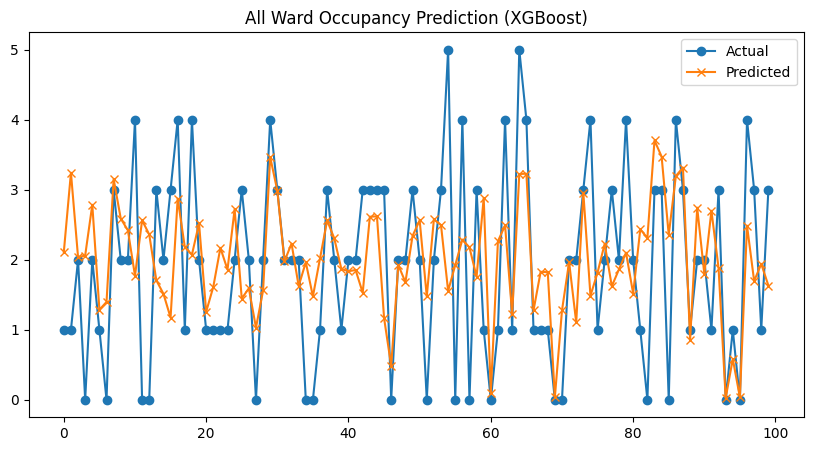

In [25]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Create a plot to visualize the actual vs predicted MICU occupancy for a subset of the test data
plt.figure(figsize=(10,5)) # Set the size of the plot
# Plot the first 100 actual values from the test set
plt.plot(y_test.values[:100], label='Actual', marker='o')
# Plot the first 100 predicted values from the test set
plt.plot(y_pred[:100], label='Predicted', marker='x')
plt.legend() # Display the legend to identify the lines
plt.title("All Ward Occupancy Prediction (XGBoost)") # Set the title of the plot
plt.show() # Display the plot

**Summary:**

The above chart compares actual all wards occupancy (blue line with circles) vs predicted occupancy (orange line with crosses) for 100 test samples using XGBoost.
Actual values fluctuate sharply between 0 and 5 patients, showing high variability and frequent spikes.
Predicted values follow the general pattern more closely than Random Forest, capturing some peaks and dips, but still smoothing out extreme spikes.

**Observations:**

XGBoost performs better than Random Forest:

*   Predictions align more closely with actual values.
*   Captures short-term trends and some spikes better than Random Forest.
*   However, XGBoost still underestimates the highest peaks and overestimates some low points.
*   XGBoost is a strong candidate for wards occupancy prediction when using lag features and time-based features.
*   Further improvements could include such as Adding more lag features (lag14, lag30).


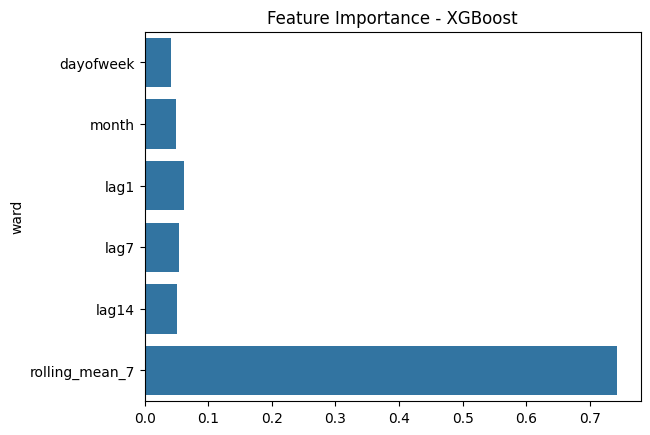

In [ ]:
import seaborn as sns # Import seaborn for enhanced visualizations
import pandas as pd # Import pandas to create a Series for feature importance

# Get the feature importances from the trained XGBoost model
# Create a pandas Series with feature importances and the corresponding feature names as index
feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
# Create a bar plot to visualize the feature importances
sns.barplot(x=feature_importance.values, y=feature_importance.index) # x-axis is importance values, y-axis is feature names
plt.title("Feature Importance - XGBoost") # Set the title of the plot
plt.show() # Display the plot

## XGBoost Feature Importance Analysis

The bar chart displays the importance of features used by the XGBoost model to predict MICU occupancy.

**Key Findings:**

*   `rolling_mean_7` (7-day average occupancy) is the most important feature, indicating that recent average occupancy is the strongest predictor.
*   Lag features (`lag1`, `lag7`, `lag14`) and time-based features (`dayofweek`, `month`) have much lower importance.

**Interpretation:**

XGBoost heavily relies on the 7-day rolling mean, suggesting that short-term trends are more influential than specific past days or calendar patterns for predicting MICU occupancy.

**Implication for Improvement:**

Focus on incorporating more rolling statistics and potentially external factors for better accuracy.